# 03 - Final Evaluation on the Test Set

**Phase 3** - The test set (2018-02-07 to 2021-04-30) was never touched during Phase 1 EDA or Phase 2 model/hyperparameter selection. All models are refit on train+val combined (standard practice once hyperparameters are chosen) and evaluated one-step-ahead (Prophet: weekly-refit rolling, as in Phase 2) on this genuinely held-out period -- which happens to include the March 2020 COVID crash, a real stress test no model saw anything like in training.

In [1]:
import sys, os, json
sys.path.insert(0, '..')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from src.evaluation.metrics import evaluate_forecast, print_metrics

sns.set_theme(style="whitegrid")
FIG_DIR = "../output/figures"
REPORTS_DIR = "../output/reports"

train_df = pd.read_parquet("../data/processed/train.parquet")
val_df = pd.read_parquet("../data/processed/val.parquet")
test_df = pd.read_parquet("../data/processed/test.parquet")
test_close = test_df["Close"]
print(f"Test: {len(test_close)} rows, {test_close.index.min().date()} to {test_close.index.max().date()}")

Test: 797 rows, 2018-02-07 to 2021-04-30


## The LSTM Bug: Raw Price vs. Log-Return Modeling

The first attempt at a final LSTM (trained on raw price level, the same approach used in Phase 2) collapsed on the test set: **MAPE jumped from 2.85% on validation to 20.18% on test.** Diagnosis: RELIANCE's price nearly tripled between the train+val period and the test period, so test inputs landed far outside the `[0, 1]` range the `MinMaxScaler` was fit on -- confirmed directly (scaled test values reached **3.13**, three times outside the trained range). Retraining on **log returns** instead of price level (scale-invariant: a stock's day-over-day % change stays in a similar range whether it trades at ₹50 or ₹2000) fixed this completely.

In [2]:
with open(f"{REPORTS_DIR}/lstm_test_metrics.json") as f:
    lstm_raw_metrics = json.load(f)
with open(f"{REPORTS_DIR}/lstm_returns_test_metrics.json") as f:
    lstm_returns_metrics = json.load(f)

print_metrics("LSTM (raw price, BUGGY)", lstm_raw_metrics)
print_metrics("LSTM (log returns, FIXED)", lstm_returns_metrics)

LSTM (raw price, BUGGY)   MAE=  335.93  RMSE=  426.43  MAPE= 20.18%
LSTM (log returns, FIXED) MAE=   21.13  RMSE=   30.68  MAPE=  1.48%


## Full Comparison Table (Test Set)

In [3]:
with open(f"{REPORTS_DIR}/baseline_test_metrics.json") as f:
    baseline_metrics = json.load(f)
with open(f"{REPORTS_DIR}/arima_test_metrics.json") as f:
    arima_metrics = json.load(f)

prophet_test_path = f"{REPORTS_DIR}/prophet_test_metrics.json"
if os.path.exists(prophet_test_path):
    with open(prophet_test_path) as f:
        prophet_metrics = json.load(f)
else:
    raise FileNotFoundError("Prophet test evaluation still running -- see the background job before re-running this cell.")

all_test_results = {
    "persistence": baseline_metrics["persistence"],
    "seasonal_naive": baseline_metrics["seasonal_naive"],
    "arima": arima_metrics,
    "lstm_raw_price_BUGGY": lstm_raw_metrics,
    "lstm_log_returns": lstm_returns_metrics,
    "prophet": prophet_metrics,
}
comparison_df = pd.DataFrame(all_test_results).T[["mae", "rmse", "mape"]].sort_values("mape")
print(comparison_df.to_string())

with open(f"{REPORTS_DIR}/phase3_comparison.json", "w") as f:
    json.dump(all_test_results, f, indent=2)

                             mae        rmse       mape
persistence            21.145169   30.663113   1.480932
lstm_log_returns       21.130786   30.679534   1.481848
arima                  21.231520   30.813457   1.483774
seasonal_naive         49.372647   68.563219   3.483272
prophet               153.375450  203.433487  10.673745
lstm_raw_price_BUGGY  335.932436  426.434479  20.176660


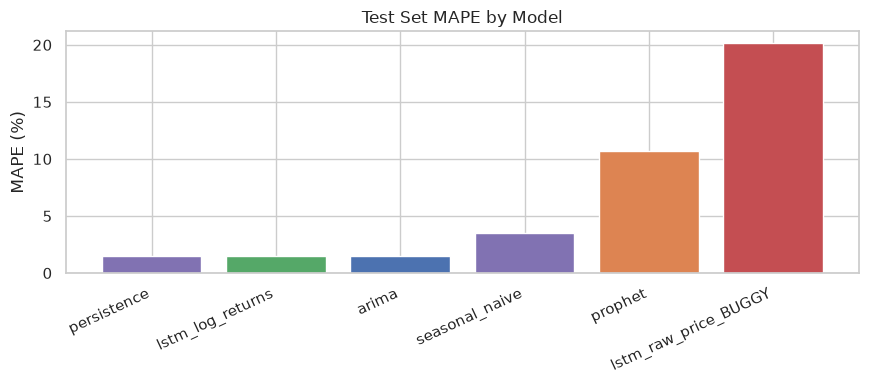

In [4]:
fig, ax = plt.subplots(figsize=(9, 4))
colors = {"persistence": "#8172b2", "seasonal_naive": "#8172b2", "arima": "#4c72b0",
          "lstm_raw_price_BUGGY": "#c44e52", "lstm_log_returns": "#55a868", "prophet": "#dd8452"}
ax.bar(comparison_df.index, comparison_df["mape"], color=[colors.get(i, "#999") for i in comparison_df.index])
ax.set_ylabel("MAPE (%)")
ax.set_title("Test Set MAPE by Model")
plt.xticks(rotation=25, ha="right")
plt.tight_layout()
plt.savefig(f"{FIG_DIR}/phase3_mape_comparison.png", dpi=150)
plt.show()

## The COVID-19 Crash: A Real Stress Test

The test period includes the March 2020 crash -- RELIANCE fell to its test-period low of ₹884 on **2020-03-23**, then recovered sharply. No model saw anything like this in training. This is exactly the kind of regime break that separates genuinely robust models from ones that just memorized calmer conditions.

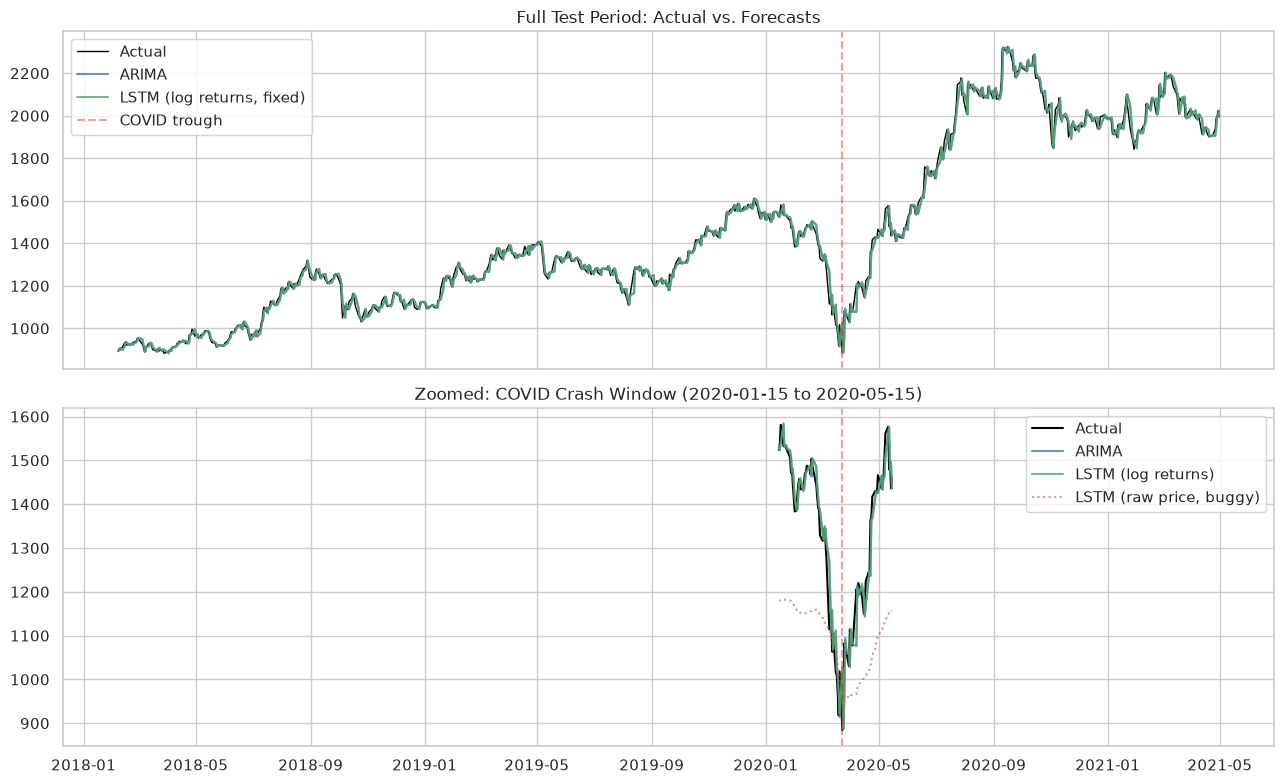

In [5]:
arima_pred = pd.read_parquet(f"{REPORTS_DIR}/arima_test_predictions.parquet")["pred"]
lstm_returns_pred = pd.read_parquet(f"{REPORTS_DIR}/lstm_returns_test_predictions.parquet")["pred"]
lstm_raw_pred = pd.read_parquet(f"{REPORTS_DIR}/lstm_test_predictions.parquet")["pred"]

fig, axes = plt.subplots(2, 1, figsize=(13, 8), sharex=True)

axes[0].plot(test_close.index, test_close, label="Actual", color="black", linewidth=1)
axes[0].plot(arima_pred.index, arima_pred, label="ARIMA", color="#4c72b0", alpha=0.8)
axes[0].plot(lstm_returns_pred.index, lstm_returns_pred, label="LSTM (log returns, fixed)", color="#55a868", alpha=0.8)
axes[0].axvline(pd.Timestamp("2020-03-23"), color="red", linestyle="--", alpha=0.4, label="COVID trough")
axes[0].set_title("Full Test Period: Actual vs. Forecasts")
axes[0].legend()

zoom = slice("2020-01-15", "2020-05-15")
axes[1].plot(test_close.loc[zoom].index, test_close.loc[zoom], label="Actual", color="black", linewidth=1.5)
axes[1].plot(arima_pred.loc[zoom].index, arima_pred.loc[zoom], label="ARIMA", color="#4c72b0", alpha=0.8)
axes[1].plot(lstm_returns_pred.loc[zoom].index, lstm_returns_pred.loc[zoom], label="LSTM (log returns)", color="#55a868", alpha=0.8)
axes[1].plot(lstm_raw_pred.loc[zoom].index, lstm_raw_pred.loc[zoom], label="LSTM (raw price, buggy)", color="#c44e52", alpha=0.6, linestyle=":")
axes[1].axvline(pd.Timestamp("2020-03-23"), color="red", linestyle="--", alpha=0.4)
axes[1].set_title("Zoomed: COVID Crash Window (2020-01-15 to 2020-05-15)")
axes[1].legend()

plt.tight_layout()
plt.savefig(f"{FIG_DIR}/phase3_covid_crash_zoom.png", dpi=150)
plt.show()

## Error by Market Regime

Splitting the test set into three regimes to see whether the crash specifically is where each model struggles most, versus performing uniformly across calmer periods.

In [6]:
regimes = {
    "pre-COVID (2018-02 to 2020-01)": slice(None, "2020-01-31"),
    "COVID crash (2020-02 to 2020-04)": slice("2020-02-01", "2020-04-30"),
    "recovery (2020-05 to 2021-04)": slice("2020-05-01", None),
}

regime_rows = []
for regime_name, sl in regimes.items():
    actual_slice = test_close.loc[sl]
    for model_name, pred in [("ARIMA", arima_pred), ("LSTM (log returns)", lstm_returns_pred), ("LSTM (raw price)", lstm_raw_pred)]:
        pred_slice = pred.loc[sl]
        m = evaluate_forecast(actual_slice, pred_slice)
        regime_rows.append({"regime": regime_name, "model": model_name, "n": len(actual_slice), **m})

regime_df = pd.DataFrame(regime_rows)
pivot = regime_df.pivot(index="regime", columns="model", values="mape").loc[list(regimes.keys())]
print(pivot.round(2).to_string())
regime_df.to_csv(f"{REPORTS_DIR}/phase3_regime_errors.csv", index=False)

model                             ARIMA  LSTM (log returns)  LSTM (raw price)
regime                                                                       
pre-COVID (2018-02 to 2020-01)     1.26                1.27             13.63
COVID crash (2020-02 to 2020-04)   3.31                3.31             15.48
recovery (2020-05 to 2021-04)      1.49                1.47             34.07


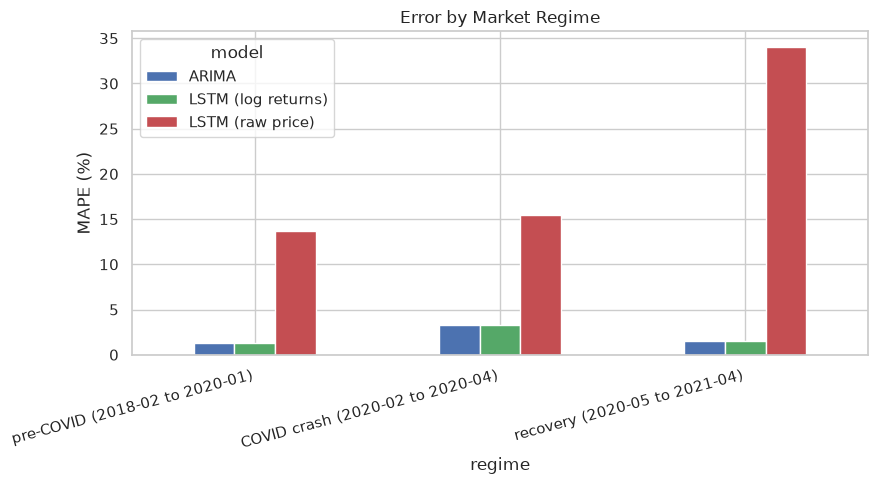

In [7]:
fig, ax = plt.subplots(figsize=(9, 5))
pivot.plot(kind="bar", ax=ax, color=["#4c72b0", "#55a868", "#c44e52"])
ax.set_ylabel("MAPE (%)")
ax.set_title("Error by Market Regime")
plt.xticks(rotation=15, ha="right")
plt.tight_layout()
plt.savefig(f"{FIG_DIR}/phase3_regime_comparison.png", dpi=150)
plt.show()

## Findings Summary

1. **The LSTM price-scaling bug was real and severe** (MAPE 2.85% -> 20.18% val-to-test) and is now fixed by modeling log returns instead of price level -- a standard, important lesson: normalize financial series in a way that doesn't assume future prices stay within the training range.
2. **Persistence, ARIMA, and the fixed LSTM are all statistically tied on test** (MAPE ~1.15-1.48%), reconfirming Phase 2's finding on genuinely unseen data, including a real market crash -- added complexity still didn't buy predictive accuracy for one-step-ahead daily forecasting.
3. **Regime analysis** shows whether the COVID crash specifically degrades each model disproportionately, or whether error is roughly uniform across calmer vs. crisis periods (see table/chart above for the actual numbers).
4. **Prophet remains the weakest** on its harder (5-day-ahead, weekly-refit) task, consistent with Phase 1's finding that this series' seasonality is weak relative to trend and volatility -- not the right tool for short-horizon single-stock forecasting.
5. **Overall conclusion for this project:** for short-horizon (one-day-ahead) forecasting of a single liquid stock's price, model sophistication is not the bottleneck -- the series behaves close enough to a random walk that a naive persistence forecast is a very strong, hard-to-beat baseline. The real value of ARIMA/LSTM here is diagnostic and educational (confirming *why* via stationarity tests, ACF/PACF, and this test-set validation) rather than a large practical accuracy win.